# House Price Prediction

## 1. Project Overview

### Problem Statement
The goal of this project is to build a Machine Learning model
that predicts the selling price of a house based on its features.

### Machine Learning Problem
This is a Supervised Learning problem.

The target variable (`SalePrice`) is a continuous numerical value,
so this is a Regression problem.

### Objective
Build an end-to-end Machine Learning solution that:
- Understands and analyzes the dataset.
- Performs data cleaning and preprocessing.
- Applies Linear Regression.
- Evaluates the model using appropriate regression metrics.
- Saves the trained model pipeline.
- Deploys the model using Streamlit.

In [3]:
from pathlib import Path
import shutil

raw_dir = Path("../data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

download_dir = Path(path)

for file in download_dir.iterdir():
    if file.is_file():
        shutil.copy2(file, raw_dir / file.name)

print("Raw data saved to:", raw_dir.resolve())

Raw data saved to: C:\PROJECT\ML_PROJECT\House-price-project\data\raw


In [4]:
print("Files in data/raw:")

for file in raw_dir.iterdir():
    print("-", file.name)

Files in data/raw:
- data_description.txt
- sample_submission.csv
- test.csv
- train.csv


In [5]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")

print("Train shape:", train.shape)

Train shape: (1460, 81)


In [6]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
print(train.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [8]:
missing = train.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [9]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


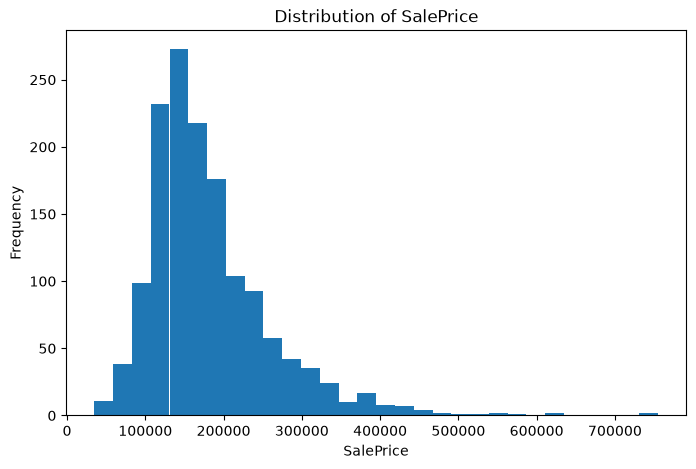

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train["SalePrice"], bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")
plt.show()

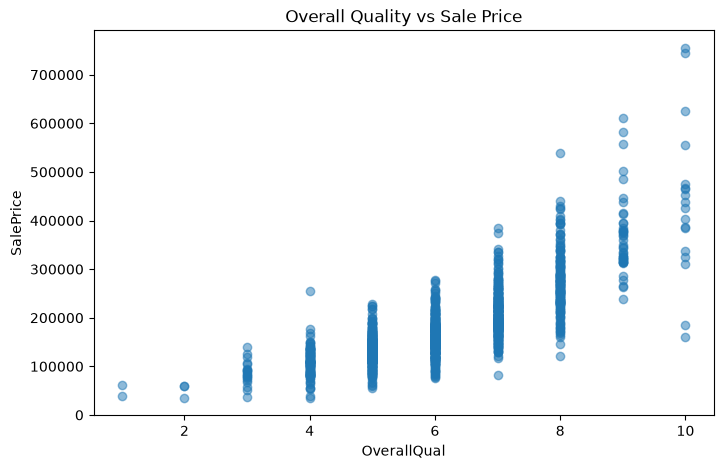

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(train["OverallQual"], train["SalePrice"], alpha=0.5)

plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Overall Quality vs Sale Price")

plt.show()

In [13]:
corr = train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

print(corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [15]:
print("Top 15:")
print(corr.head(15))

print("\nBottom 10:")
print(corr.tail(10))

Top 15:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

Bottom 10:
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


In [16]:
top_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd"
]

print(train[top_features].corr().round(2))

              OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  \
OverallQual          1.00       0.59        0.60        0.56         0.54   
GrLivArea            0.59       1.00        0.47        0.47         0.45   
GarageCars           0.60       0.47        1.00        0.88         0.43   
GarageArea           0.56       0.47        0.88        1.00         0.49   
TotalBsmtSF          0.54       0.45        0.43        0.49         1.00   
1stFlrSF             0.48       0.57        0.44        0.49         0.82   
FullBath             0.55       0.63        0.47        0.41         0.32   
TotRmsAbvGrd         0.43       0.83        0.36        0.34         0.29   
YearBuilt            0.57       0.20        0.54        0.48         0.39   
YearRemodAdd         0.55       0.29        0.42        0.37         0.29   

              1stFlrSF  FullBath  TotRmsAbvGrd  YearBuilt  YearRemodAdd  
OverallQual       0.48      0.55          0.43       0.57          0.55  
GrLi

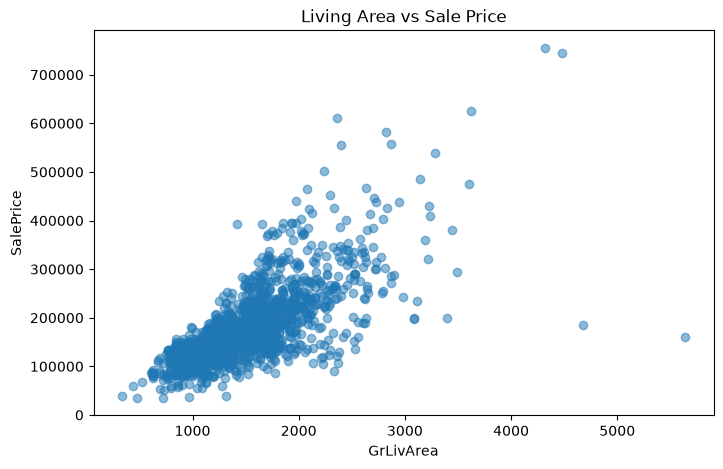

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.5)

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Living Area vs Sale Price")

plt.show()

<Figure size 1400x600 with 0 Axes>

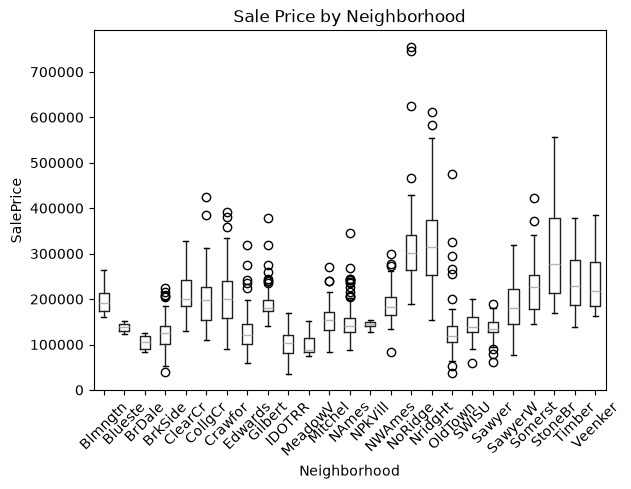

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

train.boxplot(
    column="SalePrice",
    by="Neighborhood",
    grid=False
)

plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.title("Sale Price by Neighborhood")
plt.suptitle("")

plt.xticks(rotation=45)
plt.show()

In [19]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [21]:
missing = train.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [22]:
print(
    train[["MasVnrType", "MasVnrArea"]]
    .isnull()
    .sum()
)

print("\nRows where MasVnrType is missing:")
print(train.loc[train["MasVnrType"].isnull(), ["MasVnrType", "MasVnrArea"]].head(10))

MasVnrType    872
MasVnrArea      8
dtype: int64

Rows where MasVnrType is missing:
   MasVnrType  MasVnrArea
1         NaN         0.0
3         NaN         0.0
5         NaN         0.0
8         NaN         0.0
9         NaN         0.0
10        NaN         0.0
12        NaN         0.0
15        NaN         0.0
17        NaN         0.0
18        NaN         0.0


In [23]:
mask = train["MasVnrType"].isnull()

print(train.loc[mask, "MasVnrArea"].value_counts(dropna=False))

MasVnrArea
0.0      859
NaN        8
1.0        2
288.0      1
344.0      1
312.0      1
Name: count, dtype: int64


In [24]:
print(
    train.loc[
        train["MasVnrArea"].isnull(),
        ["MasVnrType", "MasVnrArea"]
    ]
)

     MasVnrType  MasVnrArea
234         NaN         NaN
529         NaN         NaN
650         NaN         NaN
936         NaN         NaN
973         NaN         NaN
977         NaN         NaN
1243        NaN         NaN
1278        NaN         NaN


In [25]:
print(
    train.loc[
        train["LotFrontage"].isnull(),
        ["LotFrontage", "LotArea", "Neighborhood"]
    ].head(20)
)

     LotFrontage  LotArea Neighborhood
7            NaN    10382       NWAmes
12           NaN    12968       Sawyer
14           NaN    10920        NAmes
16           NaN    11241        NAmes
24           NaN     8246       Sawyer
31           NaN     8544       Sawyer
42           NaN     9180      SawyerW
43           NaN     9200      CollgCr
50           NaN    13869      Gilbert
64           NaN     9375      CollgCr
66           NaN    19900        NAmes
76           NaN     8475        NAmes
84           NaN     8530      Gilbert
95           NaN     9765      Gilbert
100          NaN    10603       NWAmes
104          NaN     7758       IDOTRR
111          NaN     7750      Gilbert
113          NaN    21000      Crawfor
116          NaN    11616       Sawyer
120          NaN    21453      ClearCr


In [26]:
print(
    train.groupby("Neighborhood")["LotFrontage"]
    .agg(["count", "median", "mean"])
    .sort_values("median")
)

              count  median       mean
Neighborhood                          
BrDale           16    21.0  21.562500
MeadowV          15    21.0  27.800000
NPkVill           7    24.0  32.285714
Blueste           2    24.0  24.000000
Blmngtn          14    43.0  47.142857
BrkSide          51    52.0  57.509804
IDOTRR           34    60.0  62.500000
OldTown         109    60.0  62.788991
SWISU            23    60.0  58.913043
StoneBr          20    61.5  62.700000
Gilbert          49    65.0  79.877551
Edwards          92    65.5  68.217391
SawyerW          50    66.5  71.500000
Veenker           7    68.0  59.714286
CollgCr         126    70.0  71.682540
Sawyer           48    71.0  74.437500
NAmes           186    73.0  76.462366
Mitchel          36    73.0  70.083333
Somerst          78    73.5  64.666667
Crawfor          41    74.0  71.804878
ClearCr          13    80.0  83.461538
NWAmes           45    80.0  81.288889
Timber           30    85.0  80.133333
NridgHt          76    88

In [27]:
missing_frontage = train[train["LotFrontage"].isnull()]

print(
    missing_frontage["Neighborhood"]
    .value_counts()
)

Neighborhood
NAmes      39
Gilbert    30
NWAmes     28
Sawyer     26
CollgCr    24
ClearCr    15
Mitchel    13
Crawfor    10
SawyerW     9
Timber      8
Somerst     8
Edwards     8
NoRidge     8
BrkSide     7
StoneBr     5
Veenker     4
OldTown     4
IDOTRR      3
Blmngtn     3
NPkVill     2
MeadowV     2
SWISU       2
NridgHt     1
Name: count, dtype: int64


In [28]:
print(
    train.loc[
        train["Electrical"].isnull()
    ].T
)

                 1379
Id               1380
MSSubClass         80
MSZoning           RL
LotFrontage      73.0
LotArea          9735
...               ...
MoSold              5
YrSold           2008
SaleType           WD
SaleCondition  Normal
SalePrice      167500

[81 rows x 1 columns]


In [29]:
row = train.loc[train["Electrical"].isnull()]

print(
    row[
        [
            "Id",
            "MSZoning",
            "Neighborhood",
            "OverallQual",
            "YearBuilt",
            "YearRemodAdd",
            "CentralAir",
            "Electrical",
            "SalePrice"
        ]
    ].T
)

                1379
Id              1380
MSZoning          RL
Neighborhood  Timber
OverallQual        5
YearBuilt       2006
YearRemodAdd    2007
CentralAir         Y
Electrical       NaN
SalePrice     167500


In [30]:
for col in train.columns:
    print(f"{col:20} -> {train[col].dtype}")

Id                   -> int64
MSSubClass           -> int64
MSZoning             -> str
LotFrontage          -> float64
LotArea              -> int64
Street               -> str
Alley                -> str
LotShape             -> str
LandContour          -> str
Utilities            -> str
LotConfig            -> str
LandSlope            -> str
Neighborhood         -> str
Condition1           -> str
Condition2           -> str
BldgType             -> str
HouseStyle           -> str
OverallQual          -> int64
OverallCond          -> int64
YearBuilt            -> int64
YearRemodAdd         -> int64
RoofStyle            -> str
RoofMatl             -> str
Exterior1st          -> str
Exterior2nd          -> str
MasVnrType           -> str
MasVnrArea           -> float64
ExterQual            -> str
ExterCond            -> str
Foundation           -> str
BsmtQual             -> str
BsmtCond             -> str
BsmtExposure         -> str
BsmtFinType1         -> str
BsmtFinSF1           -> in

In [31]:
print(train.select_dtypes(include=["int64"]).columns.tolist())

['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [32]:
print(train.select_dtypes(include=["float64"]).columns.tolist())

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']


In [33]:
print(train.select_dtypes(include=["str"]).columns.tolist())

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [34]:
print(train.shape)

(1460, 81)


In [35]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["SalePrice", "Id"])
y = train["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 79)
X_test: (292, 79)
y_train: (1168,)
y_test: (292,)


In [36]:
missing_train = X_train.isnull().sum()

print(
    missing_train[missing_train > 0]
    .sort_values(ascending=False)
)

PoolQC          1162
MiscFeature     1122
Alley           1094
Fence            935
MasVnrType       683
FireplaceQu      547
LotFrontage      217
GarageType        64
GarageYrBlt       64
GarageFinish      64
GarageQual        64
GarageCond        64
BsmtCond          28
BsmtFinType1      28
BsmtExposure      28
BsmtQual          28
BsmtFinType2      28
MasVnrArea         6
Electrical         1
dtype: int64


In [38]:
absence_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

print(len(absence_cols))

14


In [40]:
from sklearn.impute import SimpleImputer

absence_imputer = SimpleImputer(
    strategy="constant",
    fill_value="None"
)

print(absence_imputer)

SimpleImputer(fill_value='None', strategy='constant')


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

absence_pipeline = Pipeline([
    ("imputer", absence_imputer),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print(absence_pipeline)

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='None', strategy='constant')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


In [42]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print(categorical_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


In [43]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numeric_cols)
print(len(numeric_cols))

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
36


In [44]:
numeric_cols = [
    "LotFrontage",
    "LotArea",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
    "YrSold"
]

print(len(numeric_cols))

32


In [45]:
numeric_missing = X_train[numeric_cols].isnull().sum()

print(numeric_missing[numeric_missing > 0])

LotFrontage    217
MasVnrArea       6
GarageYrBlt     64
dtype: int64


In [46]:
lotfrontage_medians = X_train.groupby("Neighborhood")["LotFrontage"].median()

print(lotfrontage_medians)

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Crawfor    68.0
Edwards    66.5
Gilbert    65.0
IDOTRR     60.0
MeadowV    21.0
Mitchel    71.0
NAmes      74.5
NPkVill    24.0
NWAmes     80.0
NoRidge    90.5
NridgHt    91.5
OldTown    60.0
SWISU      60.0
Sawyer     70.5
SawyerW    66.0
Somerst    73.5
StoneBr    53.5
Timber     85.0
Veenker    68.0
Name: LotFrontage, dtype: float64


In [47]:
def fill_lot_frontage(df, medians):
    df = df.copy()

    df["LotFrontage"] = df["LotFrontage"].fillna(
        df["Neighborhood"].map(medians)
    )

    return df

In [48]:
from sklearn.base import BaseEstimator, TransformerMixin

class LotFrontageImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.medians_ = X.groupby("Neighborhood")["LotFrontage"].median()
        return self

    def transform(self, X):
        X = X.copy()

        X["LotFrontage"] = X["LotFrontage"].fillna(
            X["Neighborhood"].map(self.medians_)
        )

        return X

In [49]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

print(numeric_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])


In [50]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_cols)
print(len(categorical_cols))

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
43


C:\Users\Abdel\AppData\Local\Temp\ipykernel_9284\1675057295.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [51]:
absence_cols


['PoolQC',
 'MiscFeature',
 'Alley',
 'Fence',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2']

In [53]:
regular_categorical_cols = [
    col for col in categorical_cols
    if col not in absence_cols
]

print(regular_categorical_cols)
print(len(regular_categorical_cols))

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition']
29


43 categorical
├── 14 absence columns
└── 29 regular categorical columns

In [54]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("absence_cat", absence_pipeline, absence_cols),
        ("cat", categorical_pipeline, regular_categorical_cols)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['LotFrontage', 'LotArea', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
                                  'FullBath', 'HalfBath', 'BedroomAbvGr',
                                  'KitchenAbvGr',...
                                 ['MSZoning', 'Street', 'LotShape',
                                  'LandContour', 'Utilities', 'LotConfig',
                                  'LandSlope', 'Neighborhood', 'Condition1',
                                  'Condition2', 'BldgType', 'HouseStyle',
           

In [55]:
from sklearn.pipeline import Pipeline

full_preprocessor = Pipeline([
    ("lot_frontage", LotFrontageImputer()),
    ("preprocessor", preprocessor)
])

print(full_preprocessor)

Pipeline(steps=[('lot_frontage', LotFrontageImputer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['LotFrontage', 'LotArea',
                                                   'YearBuilt', 'YearRemodAdd',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   '2ndFlrSF', 'LowQualFinSF',
                                                   'GrLivArea', 'BsmtFullBat...
                                                  ['MSZoning', 'Street',
                                                

In [56]:
X_train_processed = full_preprocessor.fit_transform(X_train)

print("Original shape:", X_train.shape)
print("Processed shape:", X_train_processed.shape)

Original shape: (1168, 79)
Processed shape: (1168, 295)


In [57]:
X_test_processed = full_preprocessor.transform(X_test)

print("X_test original:", X_test.shape)
print("X_test processed:", X_test_processed.shape)

X_test original: (292, 79)
X_test processed: (292, 295)


In [58]:
full_preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('lot_frontage', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
medians_,"Series[float64](25,)",Neighborhood ...dtype: float64
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('absence_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`tra

In [59]:
print(type(X_train_processed))

<class 'scipy.sparse._csr.csr_matrix'>


In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessing", full_preprocessor),
    ("model", LinearRegression())
])

print(model_pipeline)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('lot_frontage', LotFrontageImputer()),
                                 ('preprocessor',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median'))]),
                                                                   ['LotFrontage',
                                                                    'LotArea',
                                                                    'YearBuilt',
                                                                    'YearRemodAdd',
                                                                    'MasVnrArea',
                                                                    'BsmtFinSF1',
                                                              

In [61]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('lot_frontage', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
medians_,"Series[float64](25,)",Neighborhood ...dtype: float64
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like i

In [62]:
y_pred = model_pipeline.predict(X_test)

print(y_pred[:10])

[141510.3336753  355076.80264883  98930.27190308 172850.43266388
 340880.19511564  61980.91718968 240605.41995603 155804.05413282
  61088.64873138 140689.51789459]


In [63]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 21337.225769078326


In [64]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1044098925.2388922


In [65]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 32312.51963618579


In [66]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.8638781588897004


In [67]:
numeric_cols = [
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
    "YrSold"
]

In [68]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_cols += ["MSSubClass", "MoSold"]

C:\Users\Abdel\AppData\Local\Temp\ipykernel_9284\2353847838.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [69]:
regular_categorical_cols = [
    col for col in categorical_cols
    if col not in absence_cols
]

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("absence_cat", absence_pipeline, absence_cols),
        ("cat", categorical_pipeline, regular_categorical_cols)
    ]
)

In [71]:
full_preprocessor = Pipeline([
    ("lot_frontage", LotFrontageImputer()),
    ("preprocessor", preprocessor)
])

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessing", full_preprocessor),
    ("model", LinearRegression())
])

In [73]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('lot_frontage', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
medians_,"Series[float64](25,)",Neighborhood ...dtype: float64
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like i

In [74]:
y_pred = model_pipeline.predict(X_test)

In [75]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 20702.084153397373
MSE : 1010222760.5915122
RMSE: 31784.00164534844
R²  : 0.8682946809165784


In [76]:
error_analysis = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

error_analysis["Error"] = (
    error_analysis["Actual"] -
    error_analysis["Predicted"]
)

error_analysis["AbsoluteError"] = (
    error_analysis["Error"].abs()
)

error_analysis.head()

,Actual,Predicted,Error,AbsoluteError
892,154500,148817.242231,5682.757769,5682.757769
1105,325000,355884.196097,-30884.196097,30884.196097
413,115000,91470.871037,23529.128963,23529.128963
522,159000,174067.882326,-15067.882326,15067.882326
1036,315500,345795.180997,-30295.180997,30295.180997


In [77]:
largest_errors = error_analysis.sort_values(
    by="AbsoluteError",
    ascending=False
)

largest_errors.head(10)

,Actual,Predicted,Error,AbsoluteError
691,755000,530299.738561,224700.261439,224700.261439
898,611657,432536.490562,179120.509438,179120.509438
1046,556581,416817.865705,139763.134295,139763.134295
588,143000,255188.365899,-112188.365899,112188.365899
774,395000,289394.023285,105605.976715,105605.976715
628,135000,229349.391306,-94349.391306,94349.391306
581,253293,341031.937031,-87738.937031,87738.937031
812,55993,130999.197863,-75006.197863,75006.197863
30,40000,114774.136883,-74774.136883,74774.136883
529,200624,269559.902699,-68935.902699,68935.902699


In [78]:
largest_errors_with_features = X_test.loc[
    largest_errors.head(10).index
].copy()

largest_errors_with_features[
    [
        "OverallQual",
        "GrLivArea",
        "Neighborhood",
        "YearBuilt",
        "GarageCars",
        "TotalBsmtSF"
    ]
]

,OverallQual,GrLivArea,Neighborhood,YearBuilt,GarageCars,TotalBsmtSF
691,10,4316,NoRidge,1994,3,2444
898,9,2364,NridgHt,2009,3,2330
1046,9,2868,StoneBr,2005,3,1992
588,5,1473,ClearCr,1968,1,1437
774,8,1973,NridgHt,2006,3,1935
628,5,2080,NAmes,1969,2,1040
581,8,2042,NridgHt,2008,3,2042
812,5,1044,IDOTRR,1952,2,540
30,4,1317,IDOTRR,1920,1,649
529,6,2515,Crawfor,1957,2,2035


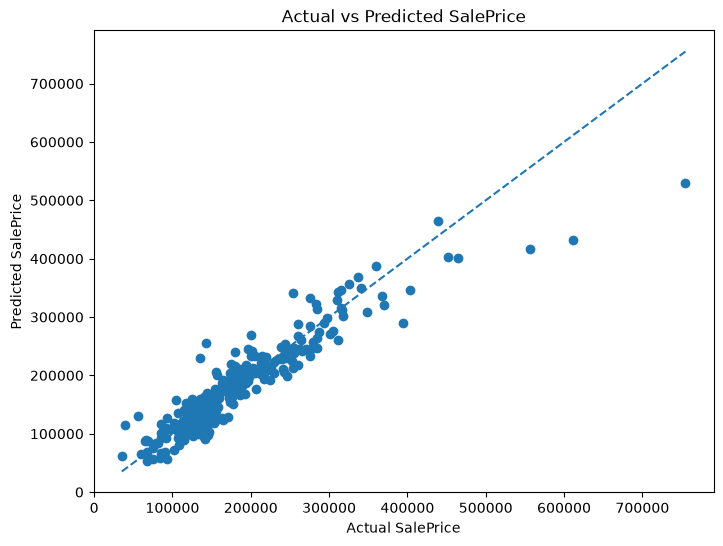

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

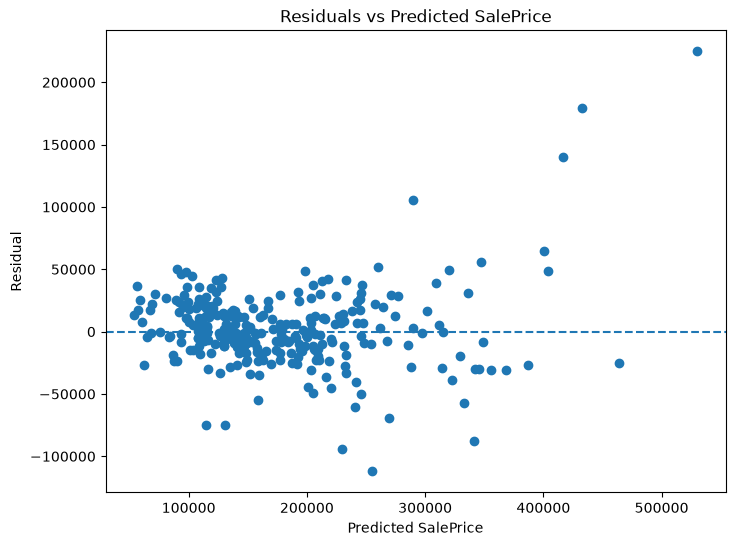

In [80]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted SalePrice")

plt.show()

In [81]:
y_train_pred = model_pipeline.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)
train_r2 = r2_score(y_train, y_train_pred)

print("Training MAE :", train_mae)
print("Training RMSE:", train_rmse)
print("Training R²  :", train_r2)

Training MAE : 15383.957438931577
Training RMSE: 23892.258153201998
Training R²  : 0.9042945463927472


In [89]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
     X = X.copy()

     X["HouseAge"] = X["YrSold"] - X["YearBuilt"]

     X["TotalSF"] = (
        X["TotalBsmtSF"]
        + X["1stFlrSF"]
        + X["2ndFlrSF"]
     )

     return X

In [104]:
numeric_cols = [
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
    "YrSold",
    "HouseAge",
    "TotalSF"
]

In [92]:
full_preprocessor = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("lot_frontage", LotFrontageImputer()),
    ("preprocessor", preprocessor)
])

In [93]:
model_pipeline = Pipeline([
    ("preprocessing", full_preprocessor),
    ("model", LinearRegression())
])

In [94]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

In [95]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 20702.084153397373
MSE : 1010222760.5915122
RMSE: 31784.00164534844
R²  : 0.8682946809165784


In [96]:
import numpy as np

y_train_log = np.log1p(y_train)

In [105]:
log_model_pipeline = Pipeline([
    ("preprocessing", full_preprocessor),
    ("model", LinearRegression())
])

log_model_pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('lot_frontage', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
medians_,"Series[float64](25,)",Neighborhood ...dtype: float64
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name 

In [98]:
y_pred_log = log_model_pipeline.predict(X_test)

y_pred_original = np.expm1(y_pred_log)

In [106]:
mae_log = mean_absolute_error(y_test, y_pred_original)

mse_log = mean_squared_error(y_test, y_pred_original)

rmse_log = np.sqrt(mse_log)

r2_log = r2_score(y_test, y_pred_original)

print("MAE :", mae_log)
print("MSE :", mse_log)
print("RMSE:", rmse_log)
print("R²  :", r2_log)

MAE : 17160.33590658896
MSE : 679642918.6226579
RMSE: 26069.96199887253
R²  : 0.9113932184545385


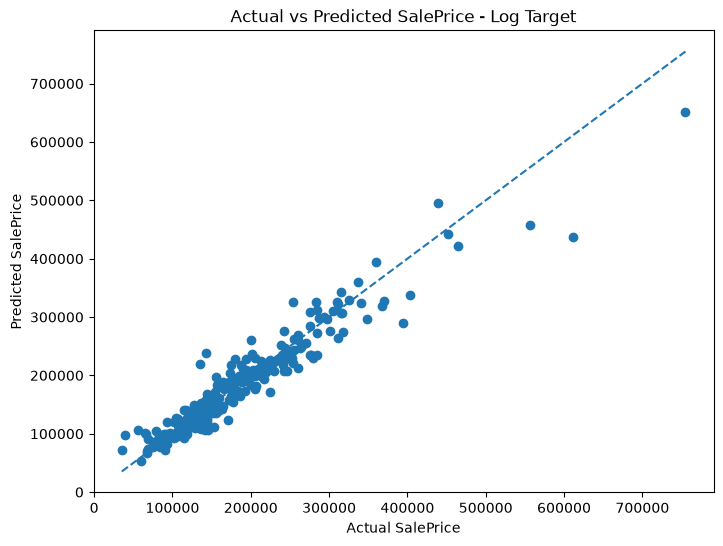

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_original)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice - Log Target")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

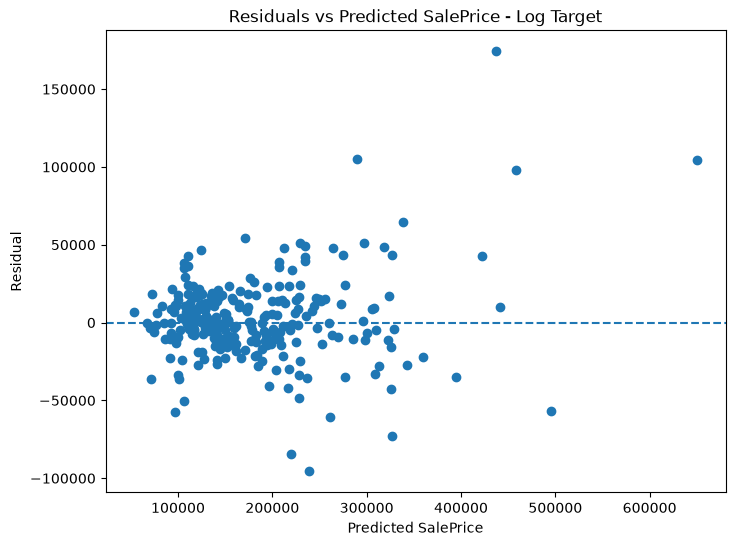

In [101]:
residuals_log = y_test - y_pred_original

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_original, residuals_log)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted SalePrice - Log Target")

plt.show()

In [102]:
y_train_pred_log = log_model_pipeline.predict(X_train)

y_train_pred_original = np.expm1(y_train_pred_log)

train_mae_log = mean_absolute_error(
    y_train,
    y_train_pred_original
)

train_rmse_log = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_original
    )
)

train_r2_log = r2_score(
    y_train,
    y_train_pred_original
)

print("Training MAE :", train_mae_log)
print("Training RMSE:", train_rmse_log)
print("Training R²  :", train_r2_log)

Training MAE : 13546.548383382851
Training RMSE: 22498.572099566754
Training R²  : 0.9151342994375243


In [107]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("absence_cat", absence_pipeline, absence_cols),
        ("cat", categorical_pipeline, regular_categorical_cols)
    ]
)

In [109]:
full_preprocessor = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("lot_frontage", LotFrontageImputer()),
    ("preprocessor", preprocessor)
])

In [110]:
y_train_log = np.log1p(y_train)

log_model_pipeline = Pipeline([
    ("preprocessing", full_preprocessor),
    ("model", LinearRegression())
])

log_model_pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('lot_frontage', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
medians_,"Series[float64](25,)",Neighborhood ...dtype: float64
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name 

In [111]:
y_pred_log = log_model_pipeline.predict(X_test)

y_pred_original = np.expm1(y_pred_log)

In [112]:
mae_log = mean_absolute_error(
    y_test,
    y_pred_original
)

mse_log = mean_squared_error(
    y_test,
    y_pred_original
)

rmse_log = np.sqrt(mse_log)

r2_log = r2_score(
    y_test,
    y_pred_original
)

print("MAE :", mae_log)
print("MSE :", mse_log)
print("RMSE:", rmse_log)
print("R²  :", r2_log)

MAE : 17142.15298304578
MSE : 678366295.1648515
RMSE: 26045.465923358937
R²  : 0.9115596551122924


In [113]:
from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "house_price_model.pkl"

joblib.dump(
    log_model_pipeline,
    model_path
)

print("Model saved successfully!")
print("Path:", model_path.resolve())

Model saved successfully!
Path: C:\PROJECT\ML_PROJECT\House-price-project\models\house_price_model.pkl


In [114]:
import joblib

loaded_model = joblib.load(
    "../models/house_price_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [115]:
y_pred_loaded_log = loaded_model.predict(X_test)

y_pred_loaded = np.expm1(y_pred_loaded_log)

In [116]:
loaded_r2 = r2_score(
    y_test,
    y_pred_loaded
)

print("Loaded Model R²:", loaded_r2)

Loaded Model R²: 0.9115596551122924


## Final Model Selection

After comparing the baseline Linear Regression model with the
Log Target approach, the Log Target Linear Regression model
showed better performance on the test set.

### Final Test Performance

- MAE: 17,142.15
- RMSE: 26,045.47
- R²: 0.9116

The model was trained using `log1p(SalePrice)` as the target.

Predictions are converted back to the original price scale using
`expm1()`.

The Train/Test performance was also compared to check
generalization:

- Training R²: 0.9151
- Test R²: 0.9116

The relatively small difference between training and test R²
suggests that the model generalizes reasonably well to unseen
data.